In [20]:
# Установка необходимых библиотек (если отсутствуют)
!pip install -q statsmodels tensorflow xgboost

# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Для статистических моделей
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Для машинного обучения
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Для нейросетей
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

# Для визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [22]:
# Загрузка данных без автоматического парсинга дат
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',', na_values=-200)

# Удаляем столбцы, которые полностью пустые (обычно два последних)
df.dropna(axis=1, how='all', inplace=True)

# Создаём столбец DateTime, объединяя Date и Time
# Приводим к строке, чтобы избежать проблем с NaN
df['DateTime'] = df['Date'].astype(str) + ' ' + df['Time'].astype(str)

# Конвертируем в datetime с указанием формата, ошибки становятся NaT
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%d/%m/%Y %H.%M.%S', errors='coerce')

# Удаляем строки, где дата не распарсилась (включая возможные пустые строки в начале/конце)
df.dropna(subset=['DateTime'], inplace=True)

# Сортируем по времени и устанавливаем DateTime в качестве индекса
df.sort_values('DateTime', inplace=True)
df.set_index('DateTime', inplace=True)

# Удаляем исходные колонки Date и Time, так как они больше не нужны
df.drop(columns=['Date', 'Time'], inplace=True)

# Вывод первых строк
print(df.head())

# Информация о колонках
print("\nИнформация о датасете:")
df.info()

                     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
DateTime                                                                      
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0   
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0   
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0   
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0   
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0   

                     NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
DateTime                                                            
2004-03-10 18:00:00    166.0        1056.0    113.0        1692.0   
2004-03-10 19:00:00    103.0        1174.0     92.0        1559.0   
2004-03-10 20:00:00    131.0        1140.0    114.0        1555.0   
2004-03-10 21:00:00    172.0        1092.0    122.0        1584.0   
2004-03-10 22:00:00    131.0    

In [23]:
# Описание колонок
column_description = {
    'CO(GT)': 'Концентрация угарного газа (мг/м³)',
    'PT08.S1(CO)': 'Показания сенсора PT08.S1 (оксид углерода)',
    'NMHC(GT)': 'Концентрация неметановых углеводородов (мкг/м³)',
    'C6H6(GT)': 'Концентрация бензола (мкг/м³)',
    'PT08.S2(NMHC)': 'Показания сенсора PT08.S2 (неметановые углеводороды)',
    'NOx(GT)': 'Концентрация оксидов азота (ppb)',
    'PT08.S3(NOx)': 'Показания сенсора PT08.S3 (оксиды азота)',
    'NO2(GT)': 'Концентрация диоксида азота (мкг/м³)',
    'PT08.S4(NO2)': 'Показания сенсора PT08.S4 (диоксид азота)',
    'PT08.S5(O3)': 'Показания сенсора PT08.S5 (озон)',
    'T': 'Температура (°C)',
    'RH': 'Относительная влажность (%)',
    'AH': 'Абсолютная влажность'
}

print("\nОписание признаков:")
for col, desc in column_description.items():
    print(f"{col}: {desc}")


Описание признаков:
CO(GT): Концентрация угарного газа (мг/м³)
PT08.S1(CO): Показания сенсора PT08.S1 (оксид углерода)
NMHC(GT): Концентрация неметановых углеводородов (мкг/м³)
C6H6(GT): Концентрация бензола (мкг/м³)
PT08.S2(NMHC): Показания сенсора PT08.S2 (неметановые углеводороды)
NOx(GT): Концентрация оксидов азота (ppb)
PT08.S3(NOx): Показания сенсора PT08.S3 (оксиды азота)
NO2(GT): Концентрация диоксида азота (мкг/м³)
PT08.S4(NO2): Показания сенсора PT08.S4 (диоксид азота)
PT08.S5(O3): Показания сенсора PT08.S5 (озон)
T: Температура (°C)
RH: Относительная влажность (%)
AH: Абсолютная влажность


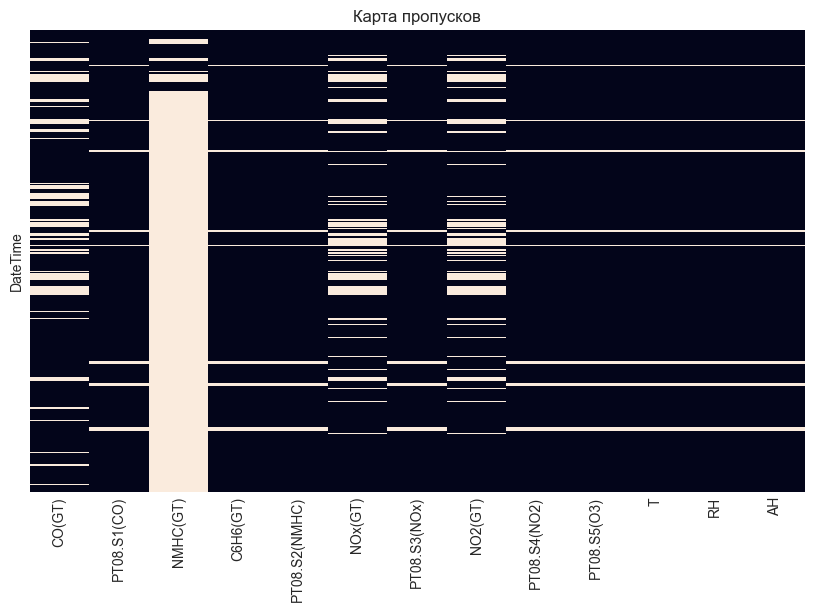

Доля пропусков по колонкам:
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
C6H6(GT)          3.911510
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64


In [24]:
# Проверим пропуски
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Карта пропусков')
plt.show()

print("Доля пропусков по колонкам:")
print(df.isnull().mean() * 100)


Пропусков после обработки: 0


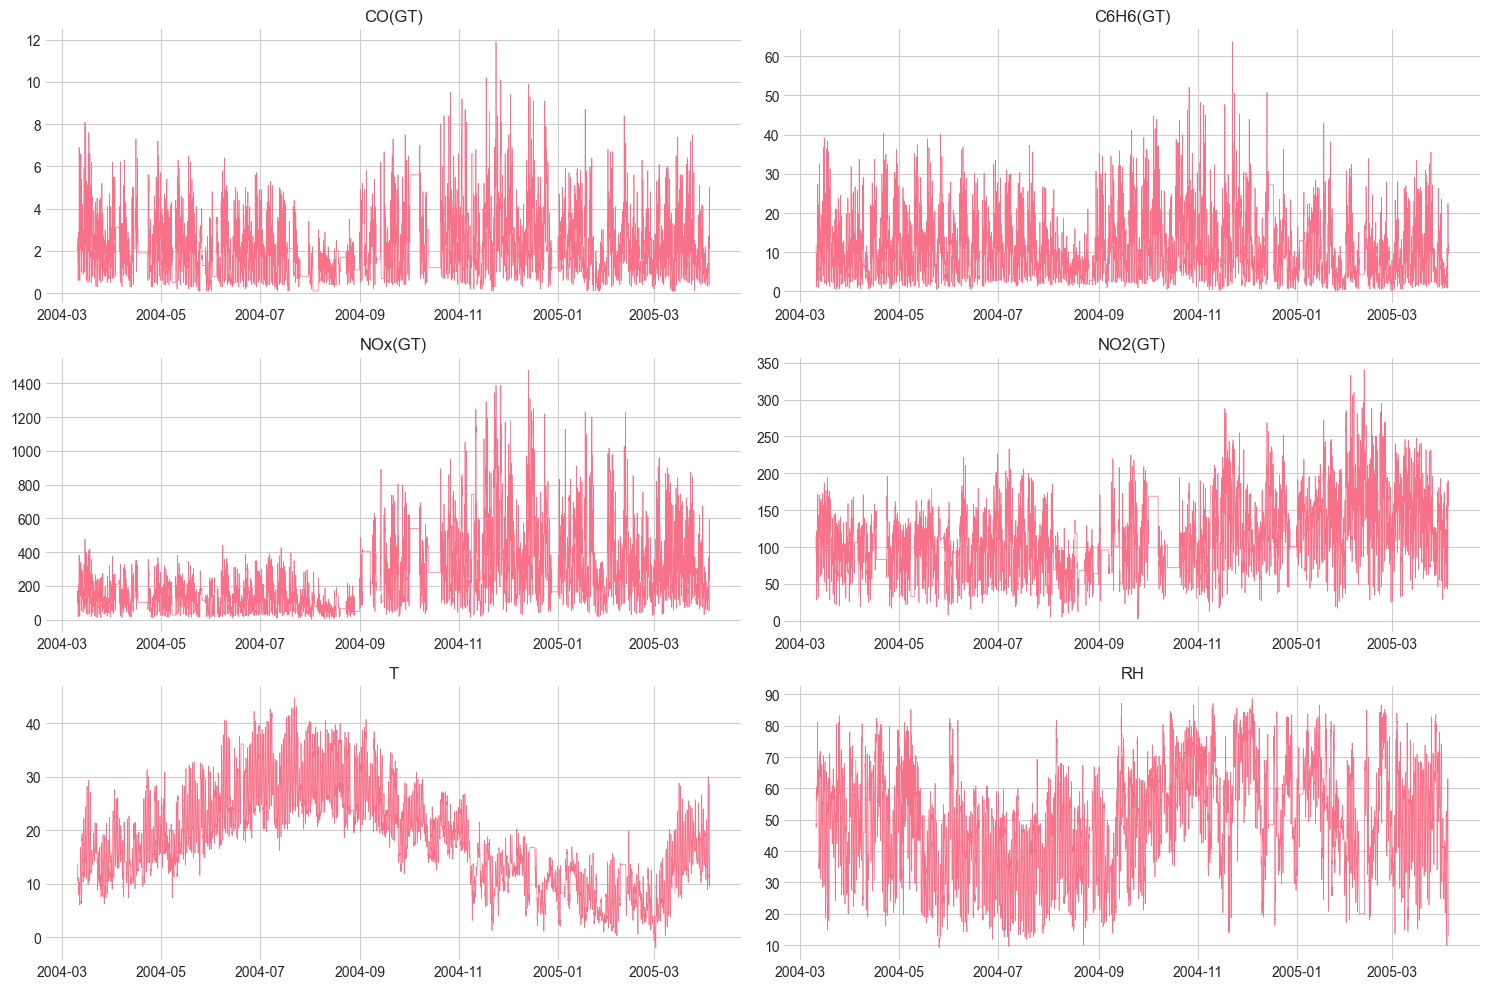

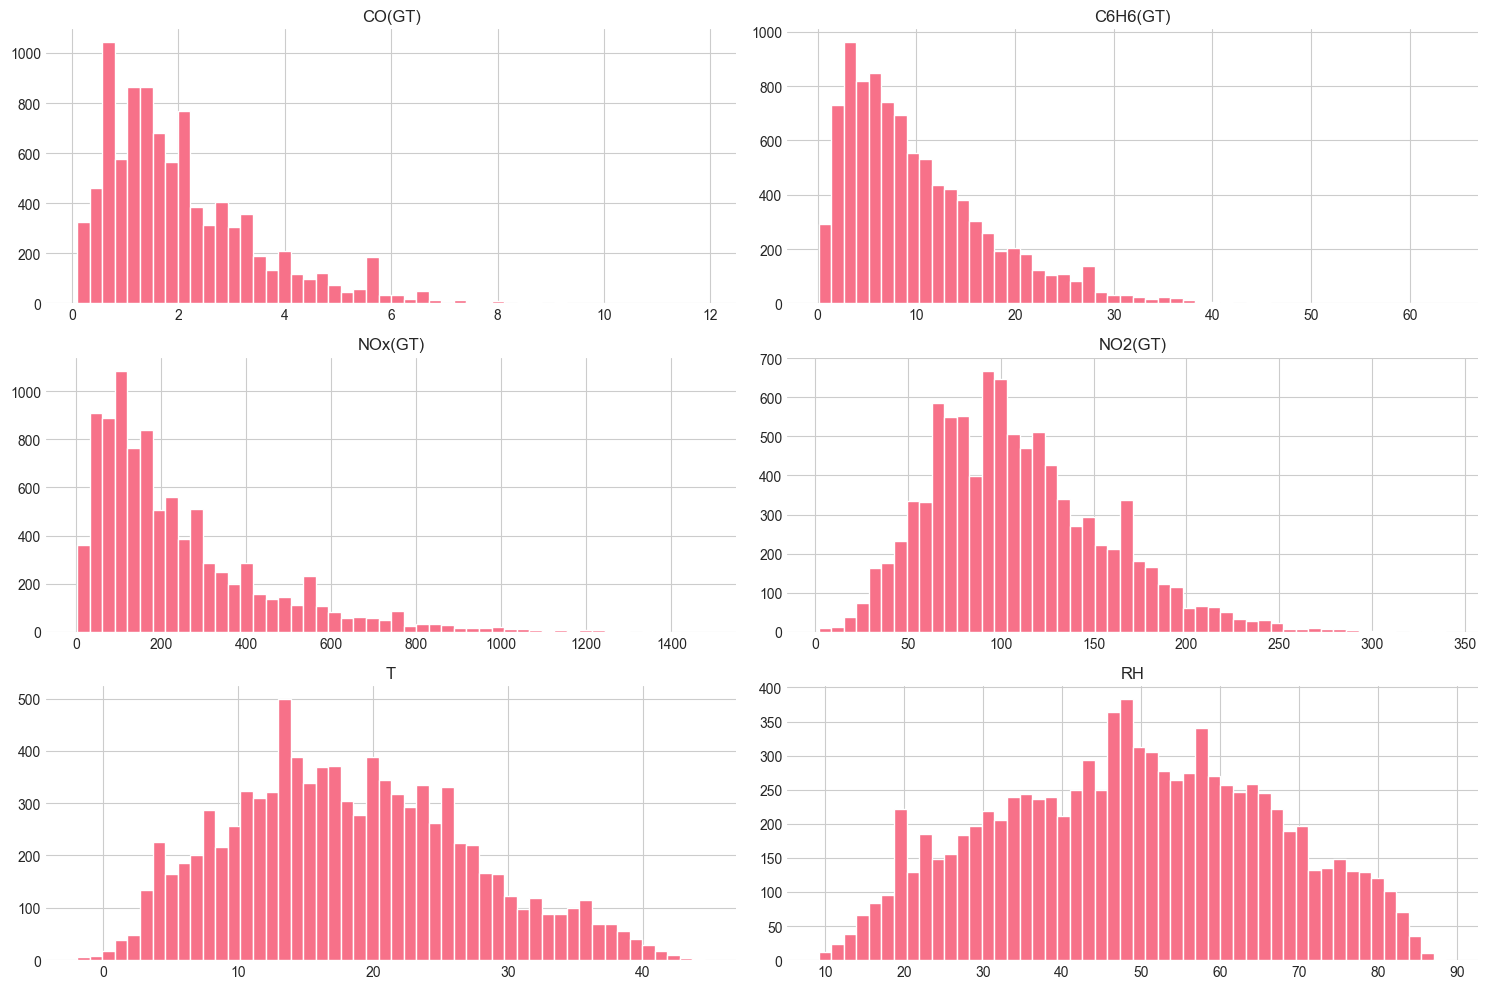

In [25]:
# Удалим признаки с большим количеством пропусков (>40%)
cols_to_drop = ['NMHC(GT)']  # только один столбец с ~90% пропусков
df.drop(columns=cols_to_drop, inplace=True)

# Остальные пропуски заполним методом forward fill (ближайшее известное значение)
df.fillna(method='ffill', inplace=True)

# Убедимся, что пропусков не осталось
print("\nПропусков после обработки:", df.isnull().sum().sum())

# Временные ряды основных загрязнителей
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
cols_plot = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']
for i, col in enumerate(cols_plot):
    ax = axes[i//2, i%2]
    ax.plot(df.index, df[col], linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Распределение признаков
df[cols_plot].hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

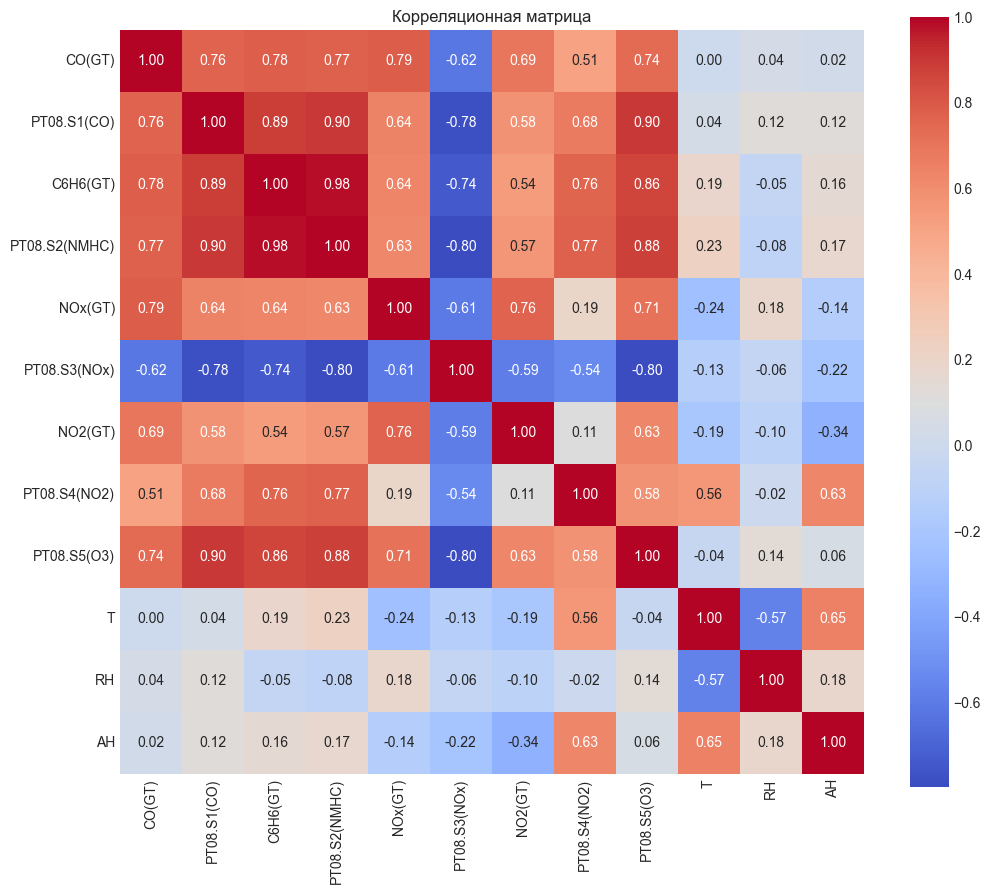

In [26]:
# Корреляционная матрица
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица')
plt.show()

In [27]:
# Анализ стационарности для целевого признака (например, CO)
result = adfuller(df['CO(GT)'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])
# p-value < 0.05 означает стационарность

ADF Statistic: -9.42384251429241
p-value: 5.412774695134745e-16
Critical Values: {'1%': np.float64(-3.431051910310215), '5%': np.float64(-2.8618502001074853), '10%': np.float64(-2.566935114435797)}


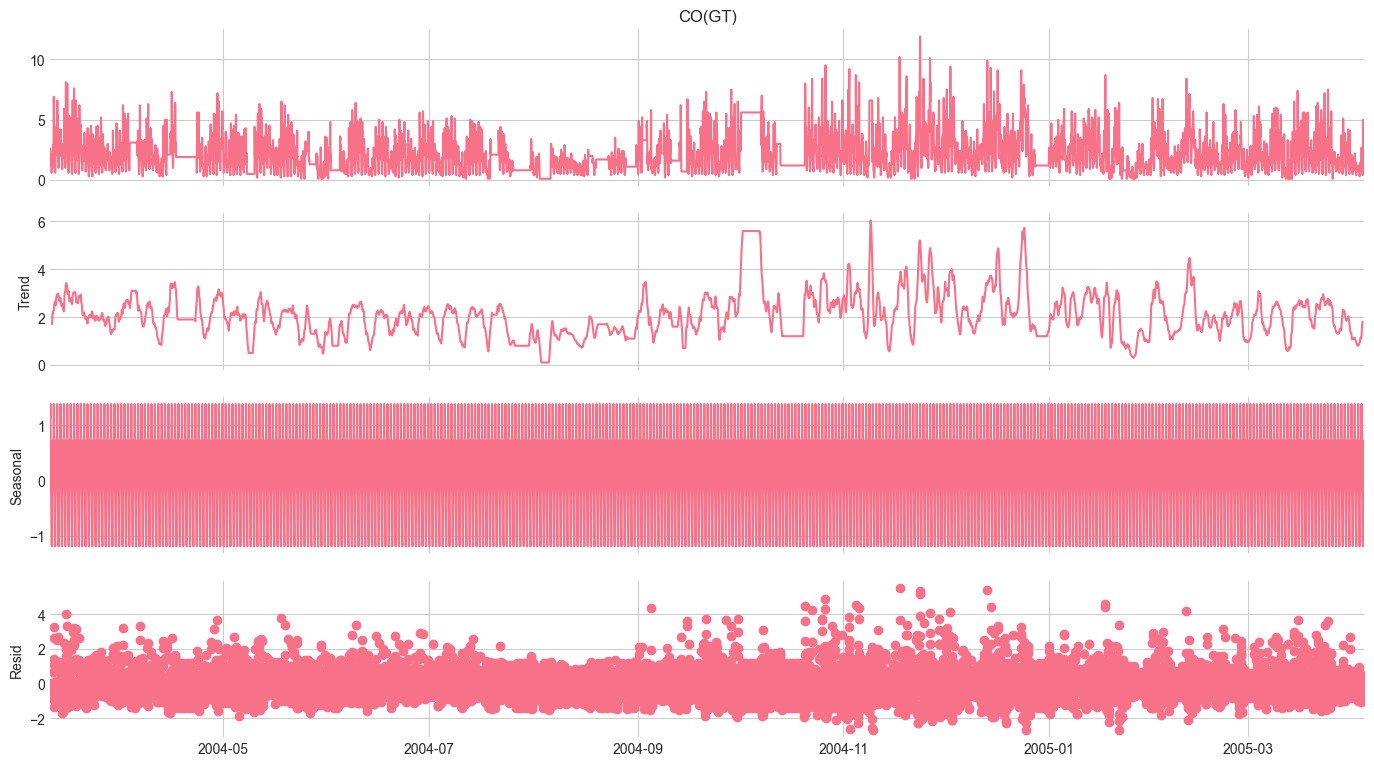

In [28]:
# Декомпозиция временного ряда (для CO)
decomposition = seasonal_decompose(df['CO(GT)'].dropna(), model='additive', period=24)  # суточная сезонность
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

In [29]:
# Создание копии для ML
df_ml = df.copy()

# Целевая переменная: прогнозирование CO на следующий час
target = 'CO(GT)'
features = ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
            'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# Создание лагов для целевой переменной
for lag in [1, 2, 3, 24]:
    df_ml[f'lag_{lag}'] = df_ml[target].shift(lag)

# Скользящие средние
df_ml['rolling_3'] = df_ml[target].shift(1).rolling(3).mean()
df_ml['rolling_24'] = df_ml[target].shift(1).rolling(24).mean()

# Временные признаки (из индекса)
df_ml['hour'] = df_ml.index.hour
df_ml['dayofweek'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month

# Удаляем строки с NaN (первые 24 из-за лагов)
df_ml.dropna(inplace=True)

# Проверка размерности
print("Размерность после создания признаков:", df_ml.shape)

Размерность после создания признаков: (9333, 21)


In [30]:
# Выделение признаков X и целевой y
X = df_ml[features + ['lag_1', 'lag_2', 'lag_3', 'lag_24', 'rolling_3', 'rolling_24', 'hour', 'dayofweek', 'month']]
y = df_ml[target]

# Масштабирование признаков
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Для обратного масштабирования целевой создадим отдельный scaler
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()

In [31]:
# Разделение на train/test (по времени: последние 20% - тест)
split_idx = int(len(X) * 0.8)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]  # исходные значения для метрик

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 7466, Test size: 1867


In [32]:
# Подготовка данных для SARIMA
series = df_ml[target].values[:split_idx]  # обучающая выборка
test_series = df_ml[target].values[split_idx:]

# Подбор параметров (упрощенно)
# Сезонность = 24 (суточная)
sarima_model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

# Прогноз на тестовый период
sarima_forecast = sarima_result.forecast(steps=len(test_series))
sarima_mae = mean_absolute_error(test_series, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test_series, sarima_forecast))
print(f"SARIMA MAE: {sarima_mae:.4f}, RMSE: {sarima_rmse:.4f}")

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 7466
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -6788.425
Date:                            Sun, 15 Mar 2026   AIC                          13586.849
Time:                                    23:42:52   BIC                          13621.423
Sample:                                         0   HQIC                         13598.726
                                           - 7466                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8277      0.006    141.595      0.000       0.816       0.839
ma.L1         -0.9843      0.003   

In [33]:
# LSTM

def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24
X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_length)

In [35]:
# Модель LSTM
lstm_model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(seq_length, X_train.shape[1])),
    layers.LSTM(32),
    layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(X_train_seq, y_train_seq,
                         validation_split=0.1,
                         epochs=50,
                         batch_size=32,
                         callbacks=[early_stop],
                         verbose=0)

In [36]:
# Прогноз
lstm_pred_scaled = lstm_model.predict(X_test_seq)
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
print(f"LSTM MAE: {lstm_mae:.4f}, RMSE: {lstm_rmse:.4f}")


58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
LSTM MAE: 0.4806, RMSE: 0.6674


In [37]:
# CNN

cnn_model = keras.Sequential([
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, X_train.shape[1])),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')

cnn_history = cnn_model.fit(X_train_seq, y_train_seq,
                            validation_split=0.1,
                            epochs=50,
                            batch_size=32,
                            callbacks=[early_stop],
                            verbose=0)

cnn_pred_scaled = cnn_model.predict(X_test_seq)
cnn_pred = scaler_y.inverse_transform(cnn_pred_scaled).flatten()

cnn_mae = mean_absolute_error(y_test_actual, cnn_pred)
cnn_rmse = np.sqrt(mean_squared_error(y_test_actual, cnn_pred))
print(f"CNN MAE: {cnn_mae:.4f}, RMSE: {cnn_rmse:.4f}")


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN MAE: 0.6421, RMSE: 0.8693


In [38]:
# Transformer

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head self-attention
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed-forward
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

def build_transformer(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation='relu')(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    return keras.Model(inputs, outputs)

input_shape = (seq_length, X_train.shape[1])
transformer_model = build_transformer(
    input_shape,
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    dropout=0.1
)
transformer_model.compile(optimizer='adam', loss='mse')

transformer_history = transformer_model.fit(X_train_seq, y_train_seq,
                                            validation_split=0.1,
                                            epochs=50,
                                            batch_size=32,
                                            callbacks=[early_stop],
                                            verbose=0)

transformer_pred_scaled = transformer_model.predict(X_test_seq)
transformer_pred = scaler_y.inverse_transform(transformer_pred_scaled).flatten()

transformer_mae = mean_absolute_error(y_test_actual, transformer_pred)
transformer_rmse = np.sqrt(mean_squared_error(y_test_actual, transformer_pred))
print(f"Transformer MAE: {transformer_mae:.4f}, RMSE: {transformer_rmse:.4f}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
Transformer MAE: 3.2583, RMSE: 3.5328


In [39]:
# Для XGBoost не нужна последовательность, используем исходные матрицы
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred_scaled = xgb_model.predict(X_test)
xgb_pred = scaler_y.inverse_transform(xgb_pred_scaled.reshape(-1, 1)).flatten()

# Приведем к одинаковой длине с другими моделями (первые seq_length точек не предсказаны)
y_test_xgb = y_test_raw.values[seq_length:]
xgb_mae = mean_absolute_error(y_test_xgb, xgb_pred[:len(y_test_xgb)])
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred[:len(y_test_xgb)]))
print(f"XGBoost MAE: {xgb_mae:.4f}, RMSE: {xgb_rmse:.4f}")

XGBoost MAE: 0.8925, RMSE: 1.3093


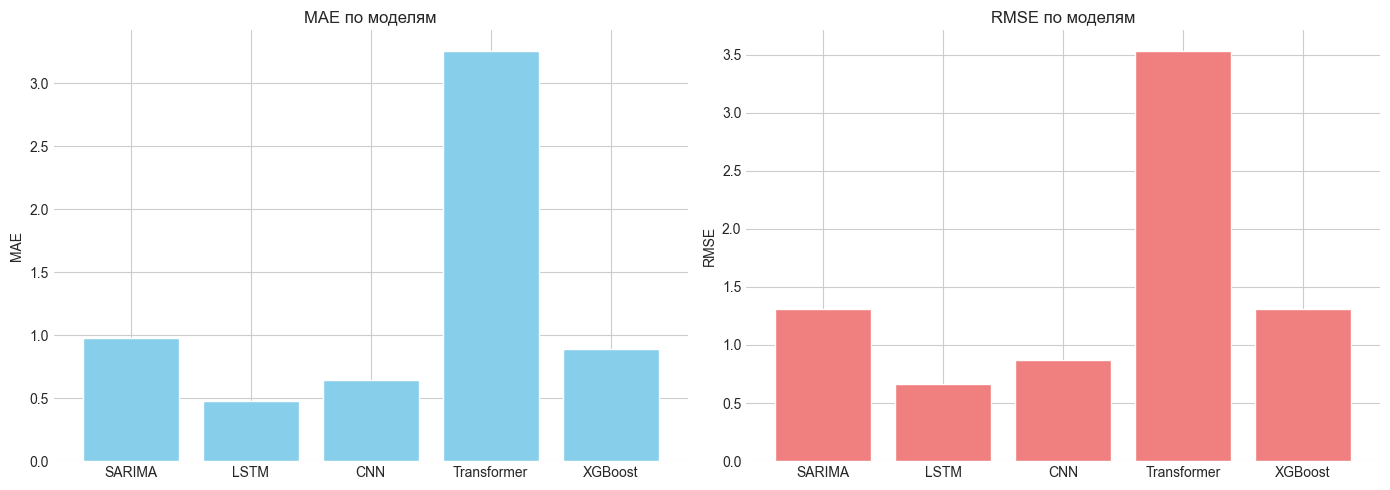

In [40]:
# Сравнение моделей

models = ['SARIMA', 'LSTM', 'CNN', 'Transformer', 'XGBoost']
mae_scores = [sarima_mae, lstm_mae, cnn_mae, transformer_mae, xgb_mae]
rmse_scores = [sarima_rmse, lstm_rmse, cnn_rmse, transformer_rmse, xgb_rmse]

# График сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(models, mae_scores, color='skyblue')
axes[0].set_title('MAE по моделям')
axes[0].set_ylabel('MAE')
axes[1].bar(models, rmse_scores, color='lightcoral')
axes[1].set_title('RMSE по моделям')
axes[1].set_ylabel('RMSE')
plt.tight_layout()
plt.show()

In [41]:
# Таблица метрик
metrics_df = pd.DataFrame({'Model': models, 'MAE': mae_scores, 'RMSE': rmse_scores})
print(metrics_df)

         Model       MAE      RMSE
0       SARIMA  0.978203  1.309797
1         LSTM  0.480563  0.667408
2          CNN  0.642105  0.869256
3  Transformer  3.258300  3.532756
4      XGBoost  0.892502  1.309292


In [42]:
# Поиск аномалий
# Подготовка данных для автоэнкодера (те же последовательности)
autoencoder_input = X_train_seq  # форма (samples, seq_length, features)

# Простая архитектура автоэнкодера
input_layer = Input(shape=(seq_length, X_train.shape[1]))
# Encoder
x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
x = layers.MaxPooling1D(2, padding='same')(x)
x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)
# Decoder
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)
decoded = layers.Conv1D(X_train.shape[1], 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Обучение
autoencoder.fit(autoencoder_input, autoencoder_input,
                epochs=20,
                batch_size=32,
                validation_split=0.1,
                verbose=0)

# Ошибка реконструкции на train
train_recon = autoencoder.predict(autoencoder_input, verbose=0)
train_errors = np.mean(np.square(train_recon - autoencoder_input), axis=(1,2))  # средний MSE по окну

# Порог (например, 95-й процентиль)
threshold = np.percentile(train_errors, 95)
print(f"Порог аномалии (95-й процентиль ошибки на train): {threshold:.6f}")

Порог аномалии (95-й процентиль ошибки на train): 0.005999


In [43]:
# Ошибка на test
test_recon = autoencoder.predict(X_test_seq, verbose=0)
test_errors = np.mean(np.square(test_recon - X_test_seq), axis=(1,2))

# Выявление аномалий на тесте
anomalies = test_errors > threshold
print(f"Найдено аномалий на тесте: {np.sum(anomalies)} из {len(test_errors)}")

Найдено аномалий на тесте: 1418 из 1843


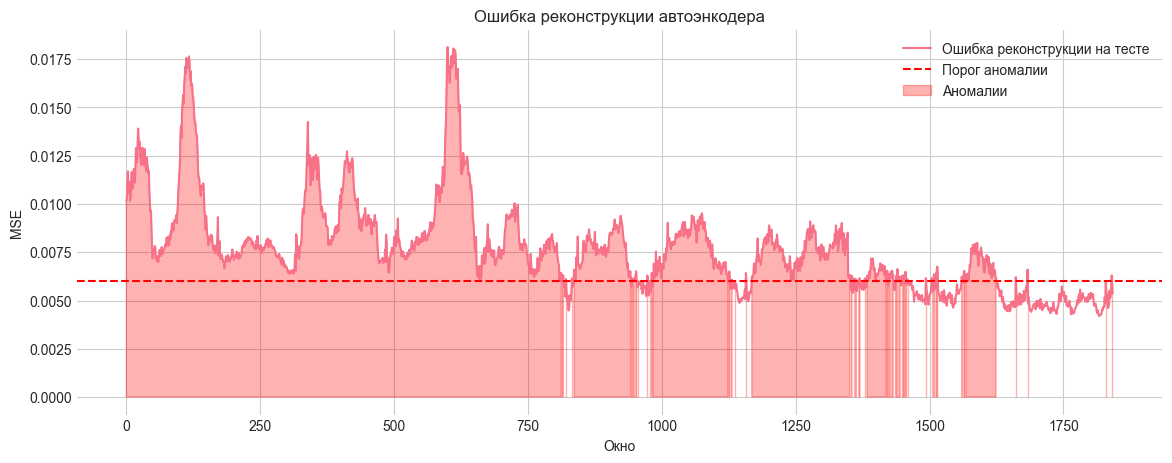

In [44]:
# Визуализация ошибок
plt.figure(figsize=(14,5))
plt.plot(test_errors, label='Ошибка реконструкции на тесте')
plt.axhline(y=threshold, color='r', linestyle='--', label='Порог аномалии')
plt.fill_between(range(len(test_errors)), 0, test_errors, where=anomalies, color='red', alpha=0.3, label='Аномалии')
plt.title('Ошибка реконструкции автоэнкодера')
plt.xlabel('Окно')
plt.ylabel('MSE')
plt.legend()
plt.show()

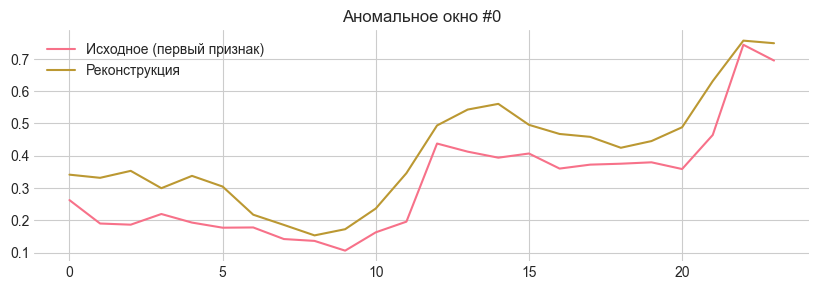

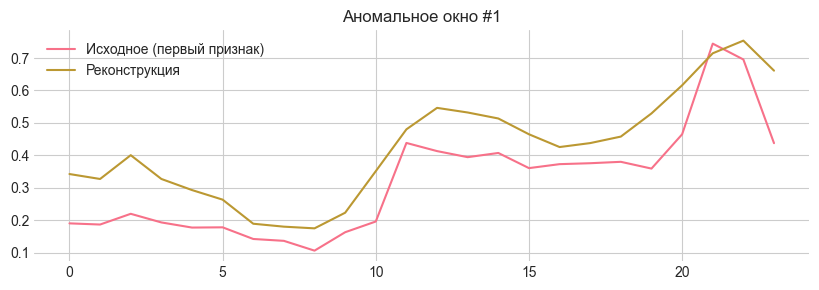

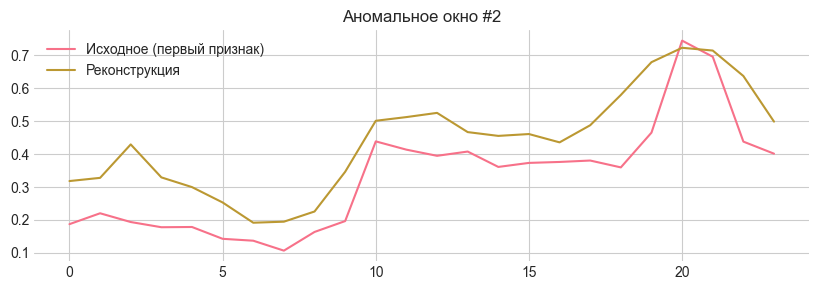

In [45]:
# Отобразим несколько примеров аномальных окон
anom_indices = np.where(anomalies)[0]
for idx in anom_indices[:3]:  # первые три
    plt.figure(figsize=(10,3))
    plt.plot(X_test_seq[idx, :, 0], label='Исходное (первый признак)')
    plt.plot(test_recon[idx, :, 0], label='Реконструкция')
    plt.title(f'Аномальное окно #{idx}')
    plt.legend()
    plt.show()

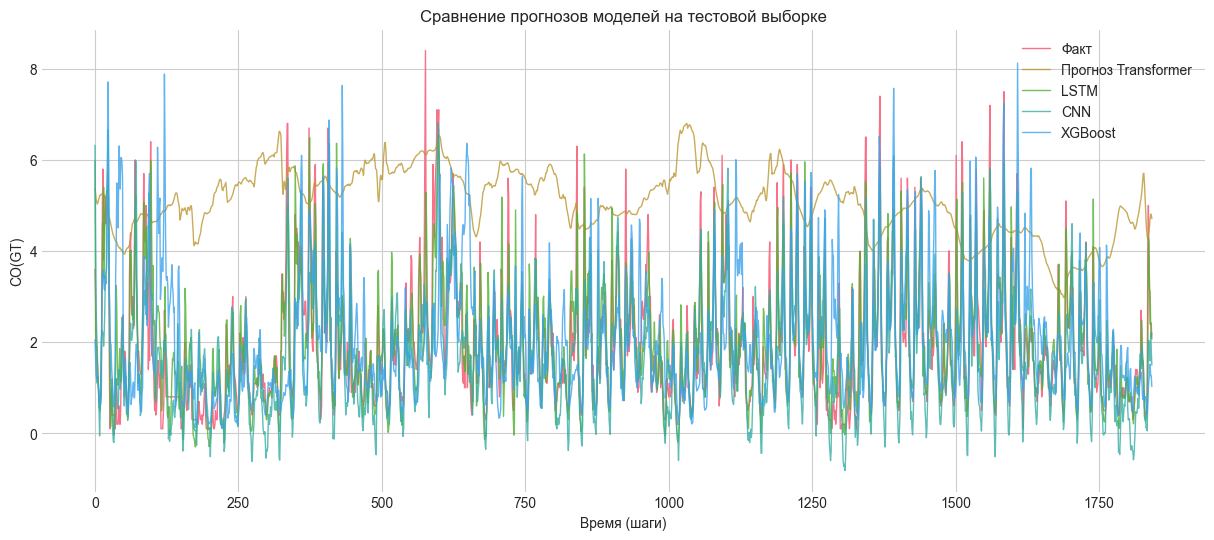

In [46]:
# Визуализация ошибок прогнозирования и важности признаков
plt.figure(figsize=(15,6))
plt.plot(y_test_actual, label='Факт', linewidth=1)
plt.plot(transformer_pred, label='Прогноз Transformer', linewidth=1, alpha=0.8)
plt.plot(lstm_pred, label='LSTM', linewidth=1, alpha=0.8)
plt.plot(cnn_pred, label='CNN', linewidth=1, alpha=0.8)
plt.plot(xgb_pred[:len(y_test_actual)], label='XGBoost', linewidth=1, alpha=0.8)
plt.legend()
plt.title('Сравнение прогнозов моделей на тестовой выборке')
plt.xlabel('Время (шаги)')
plt.ylabel('CO(GT)')
plt.show()

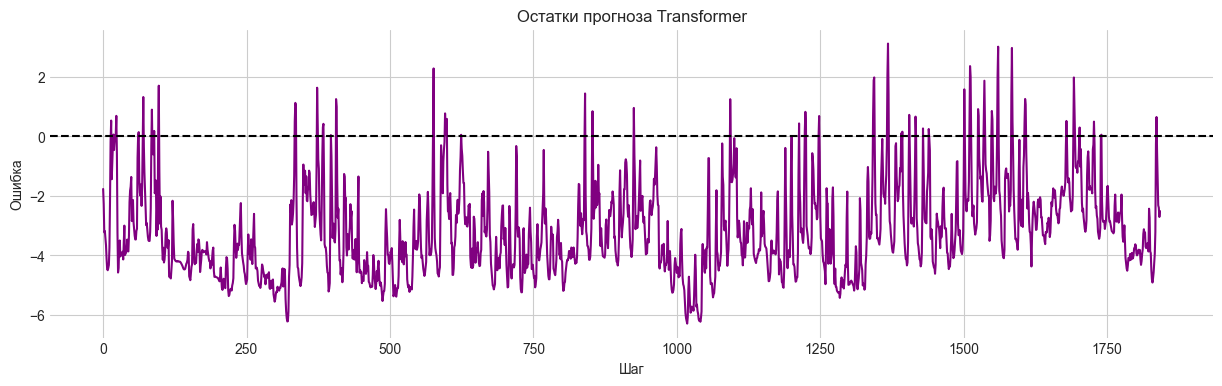

In [47]:
# График ошибок (остатков) для Transformer
residuals = y_test_actual - transformer_pred
plt.figure(figsize=(15,4))
plt.plot(residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Остатки прогноза Transformer')
plt.xlabel('Шаг')
plt.ylabel('Ошибка')
plt.show()

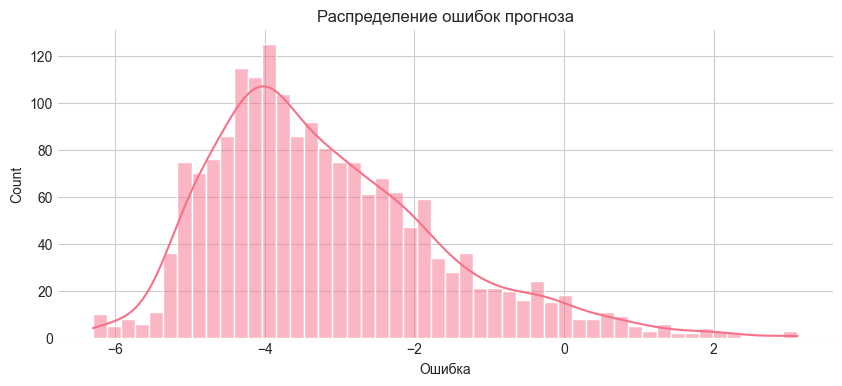

In [49]:
# Распределение остатков
plt.figure(figsize=(10,4))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Распределение ошибок прогноза')
plt.xlabel('Ошибка')
plt.show()

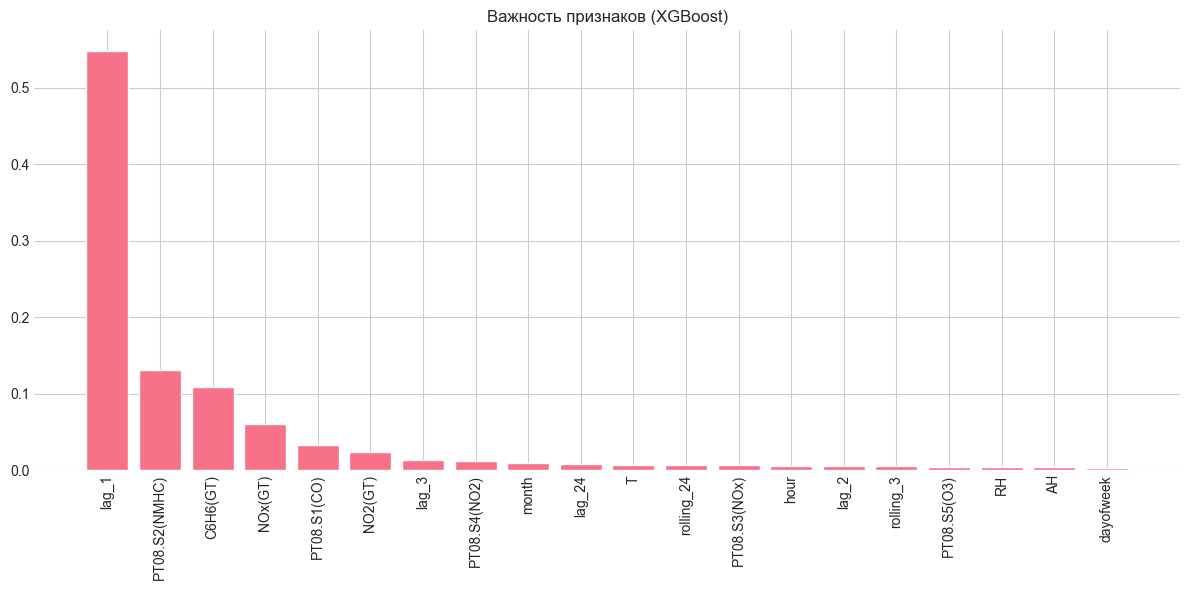

In [50]:
# Важность признаков (на примере XGBoost)
# Получим важность признаков из XGBoost
feature_names = X.columns
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title('Важность признаков (XGBoost)')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()